# K-Means Clustering

# Goal
let's attempt to find reasonable clusters of iris segmentation and study.

# The Data 
This data sets consists of 3 different types of irises’ (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray
The rows being the samples and the columns being: Sepal Length, Sepal Width, Petal Length and Petal Width.

LINK: http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
X, y = load_iris(return_X_y=True)

In [3]:
X.shape , y.shape

((150, 4), (150,))

In [4]:
steps = [('dimension reduction', PCA(n_components=2)),
         ('clustering', KMeans(n_clusters=5))]

cls = Pipeline(steps=steps).fit(X)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


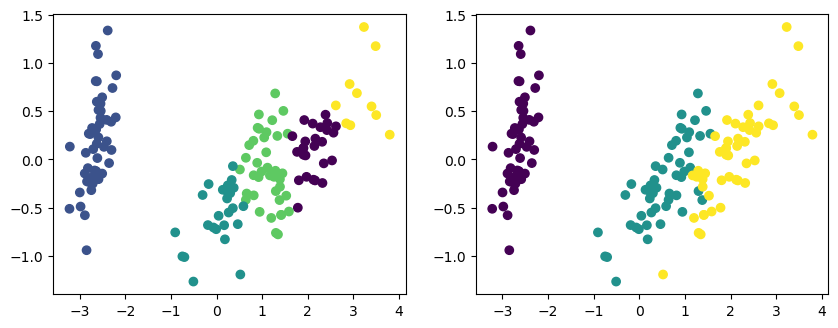

In [5]:
X_2d = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(10, 8))
plt.subplot(221)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=cls.predict(X));
plt.subplot(222)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y);

In [6]:
from sklearn.metrics import adjusted_rand_score, rand_score, calinski_harabasz_score

In [7]:
adjusted_rand_score(y, cls.predict(X)), rand_score(y, cls.predict(X))

(0.6148346580920249, 0.8422371364653244)

In [8]:
calinski_harabasz_score(X, cls.predict(X))

491.3283486865907

In [9]:
inertia = []
calniski = []
K = []
for k in range(2, 16):
    cls = KMeans(n_clusters=k).fit(X)
    inertia.append(cls.inertia_)
    calniski.append(calinski_harabasz_score(X, cls.predict(X)))
    K.append(k)

/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:8

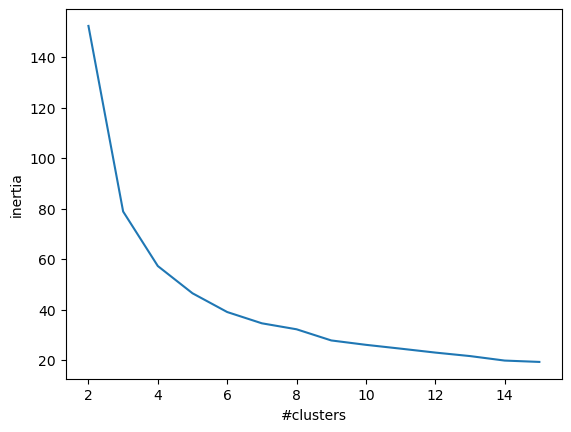

In [10]:
plt.plot(K, inertia);
plt.xlabel('#clusters');
plt.ylabel('inertia');

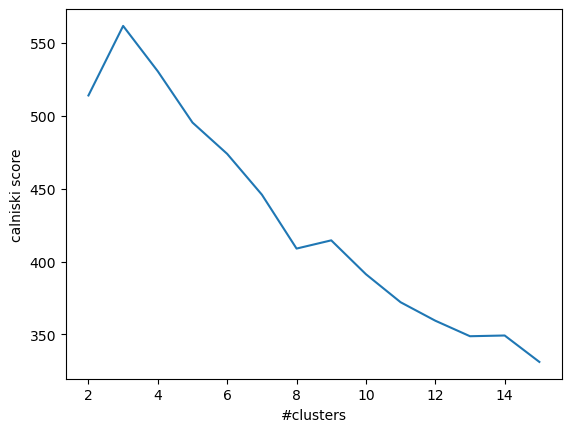

In [11]:
plt.plot(K, calniski);
plt.xlabel('#clusters');
plt.ylabel('calniski score');

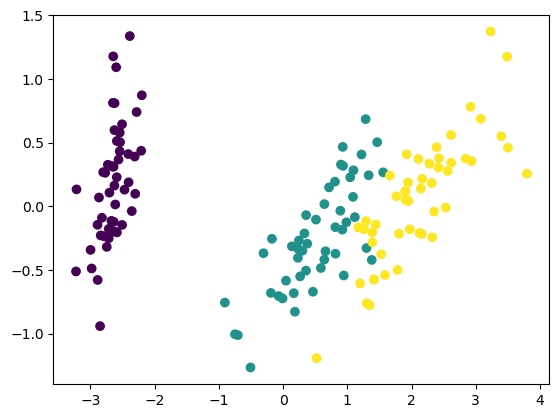

In [12]:
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y);

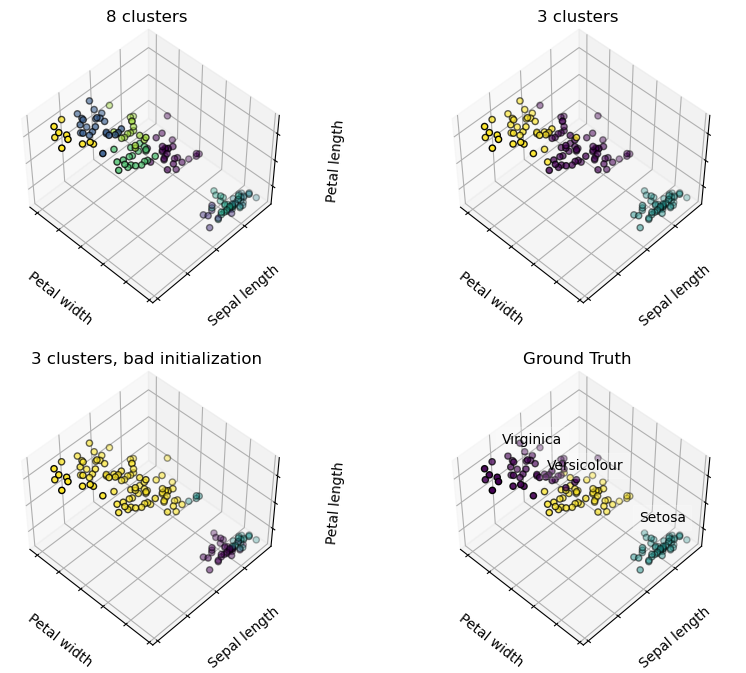

In [13]:
estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8, n_init="auto")),
    ("k_means_iris_3", KMeans(n_clusters=3, n_init="auto")),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Petal width")
    ax.set_ylabel("Sepal length")
    ax.set_zlabel("Petal length")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X[y == label, 3].mean(),
        X[y == label, 0].mean(),
        X[y == label, 2].mean() + 2,
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )
# Reorder the labels to have colors matching the cluster results
y = np.choose(y, [1, 2, 0]).astype(float)
ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Petal width")
ax.set_ylabel("Sepal length")
ax.set_zlabel("Petal length")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()